# CRE III - Assignment 1: Parameter Estimation
Benjamin Heuschmid , Sanskar Nashier, Maximilian Franz (Group 2)

## 1 Introduction

In chemical engineering, parameter estimation is a fundamental tool for characterising reaction systems. When an isothermally operated batch stirred tank reactor is used to study an unknown reaction network, the concentration profiles of all species over time contain the information needed to identify both the network structure and the kinetic rate constants. Since rate constants are not directly measurable, they must be extracted by fitting a mathematical model to the experimental observations.

In this assignment, experimentally obtained concentration profiles of six species (A, B, C, D, E, F) are analysed for six experiments with different initial conditions. From these profiles, a reaction hypothesis is developed. The proposed reaction kinetics are then assessed by comparing the model predictions with the experimental data using nonlinear least-squares parameter estimation.

## 2 Experimental Data

In the first step, all required packages are imported and the path to the experimental data is defined.

In [1]:
# Imports of packages
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import ICIW_Plots.colors as iciw_colors
plt.style.use("ICIWstyle")
import scipy.integrate as integ
from lmfit import Model, Minimizer, Parameters, report_fit

# Path to folder with csv-data
path = "2026_Task_data"


The experimental data is extracted from six CSV files and stored in lists: `t_eval` for time points, `exp_concs` for concentration profiles, and `c_inits` for initial concentrations. The concentration data is then flattened into a single array for use in the parameter estimation.

In [2]:
# create list of files in directory
os_list = os.listdir(path)
# provide length of list, which equals the number of experiments (nex)
nex = len(os_list)

# create empty list for concentrations, times and initials to store experimental results
exp_concs = []
t_eval = []
c_inits = []
for i in np.arange(0, nex):
    # iterate over all csv-files and append them, after transposing, as array to the list
    aux = pd.read_csv(path + r'\Exp_res_' + str(i) + '.csv')
    t_eval.append(aux.values.transpose()[0, :])         # time in s
    c_inits.append(aux.values.transpose()[1:, 0])       # initial concentration of component i in mol/m^3
    exp_concs.append(aux.values.transpose()[1:, :])     # timedependent concentration of component i in mol/m^3

# Create flattened array of results
nex = len(exp_concs)
exp_concs_flat = np.array([])
for i in np.arange(0, nex):
    exp_concs_flat = np.append(exp_concs_flat, exp_concs[i])


All six experiments are plotted below as concentration versus time diagrams. The cumulative concentration (sum of all species) is included as a mass balance check.

## Plotting Configuration

To improve readability and consistency, fixed colors are assigned to each chemical species. These colors are used throughout all plots in the notebook. Each experiment is plotted separately to inspect concentration trends, identify reactant and product behavior, and verify data consistency.


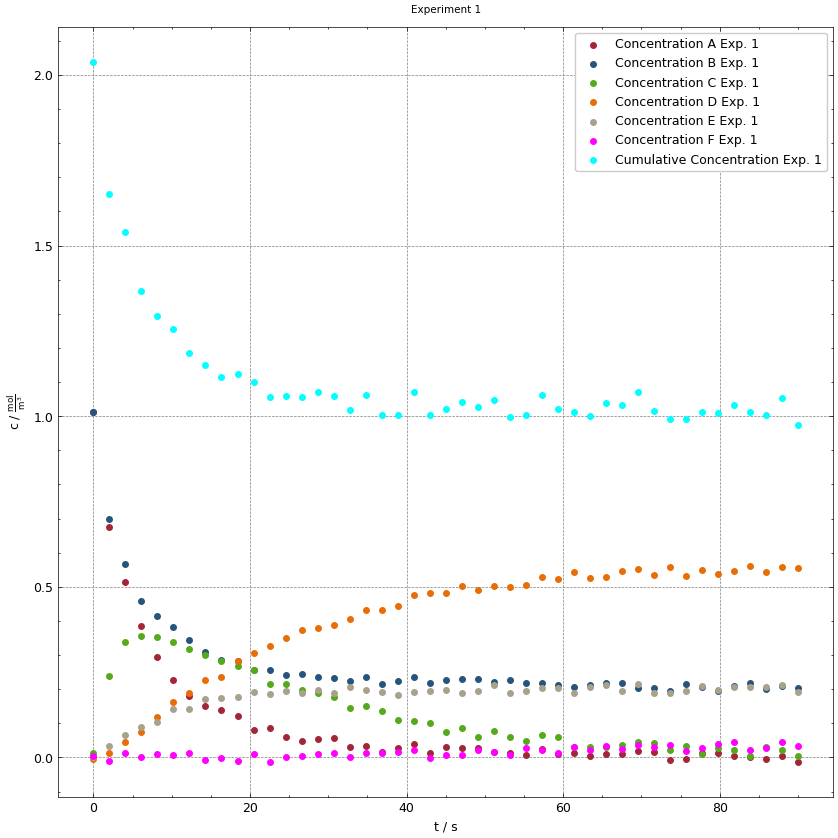

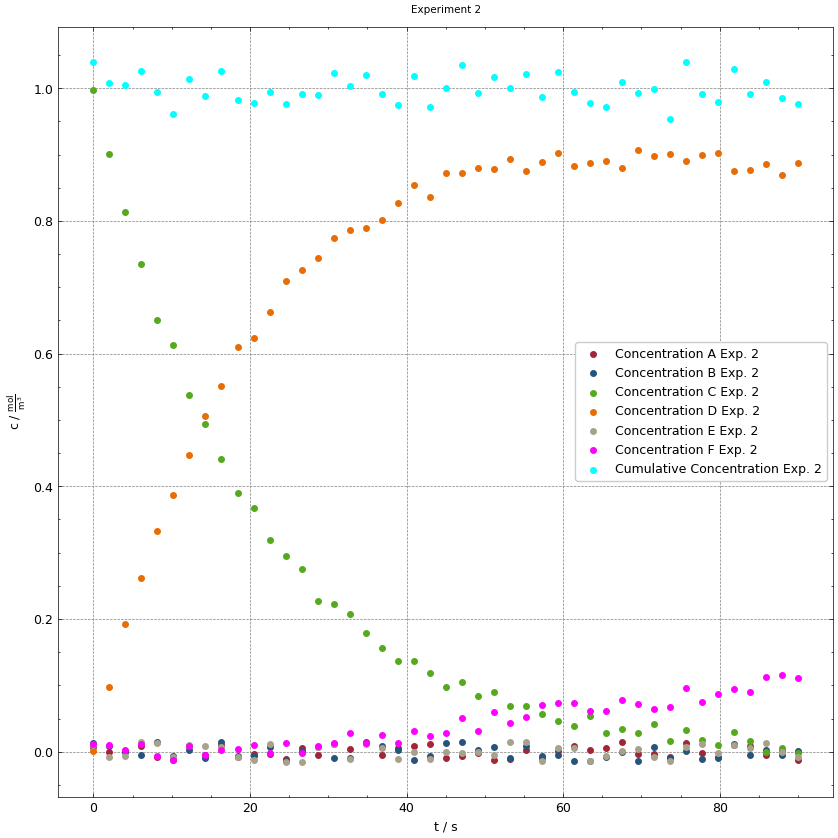

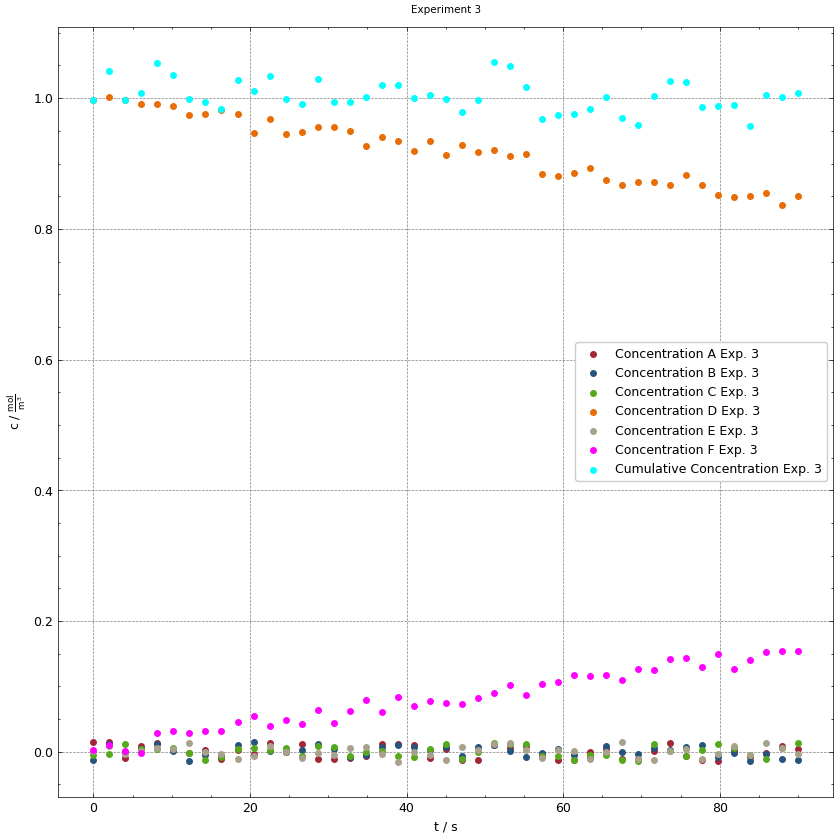

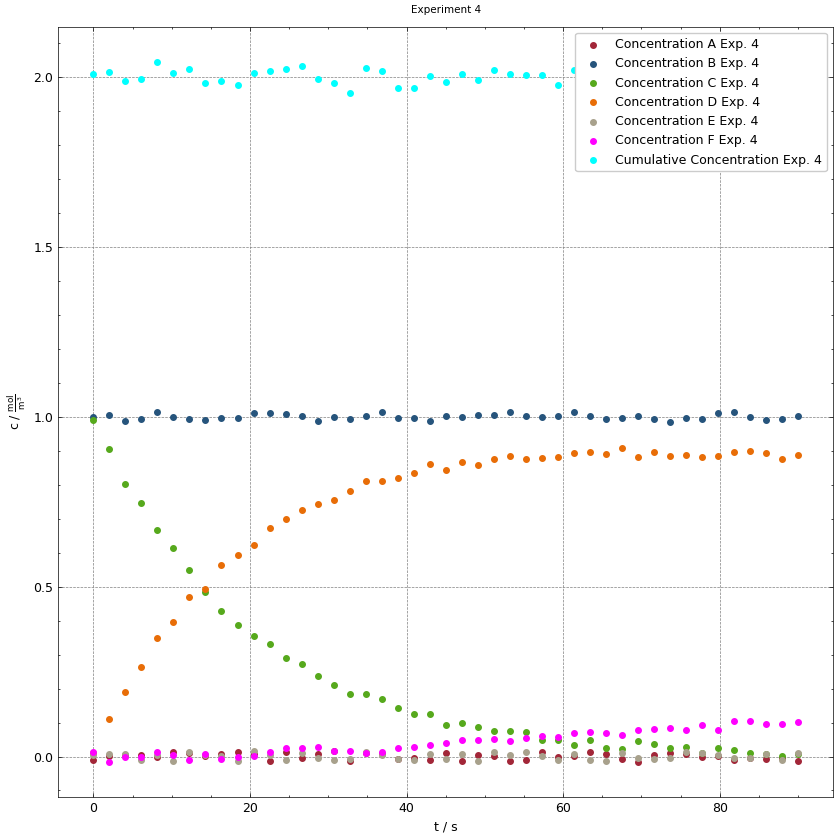

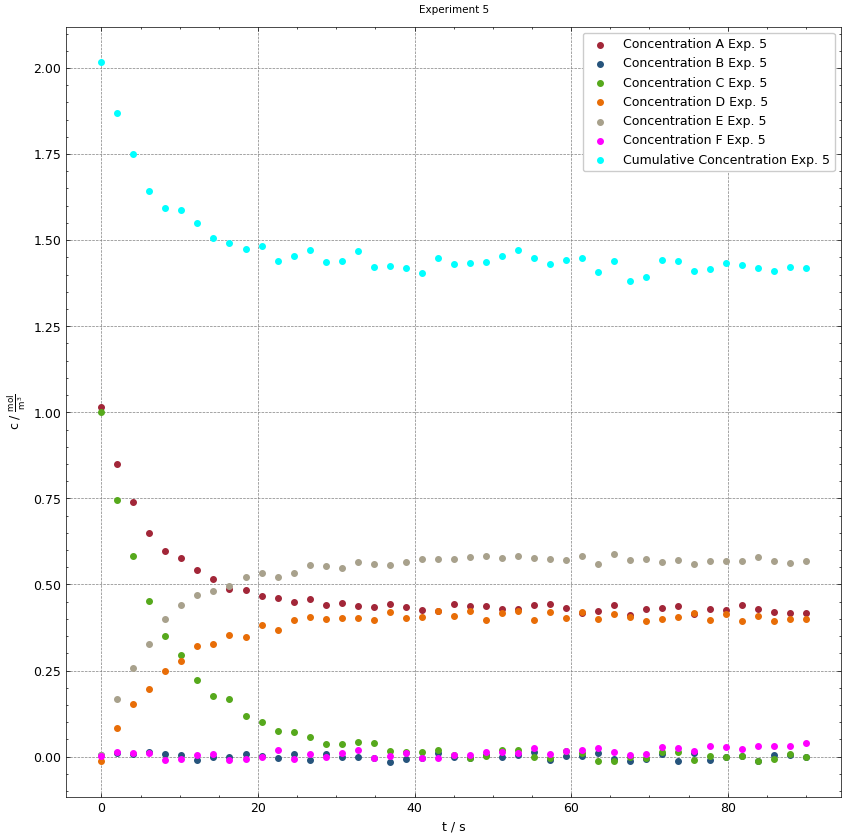

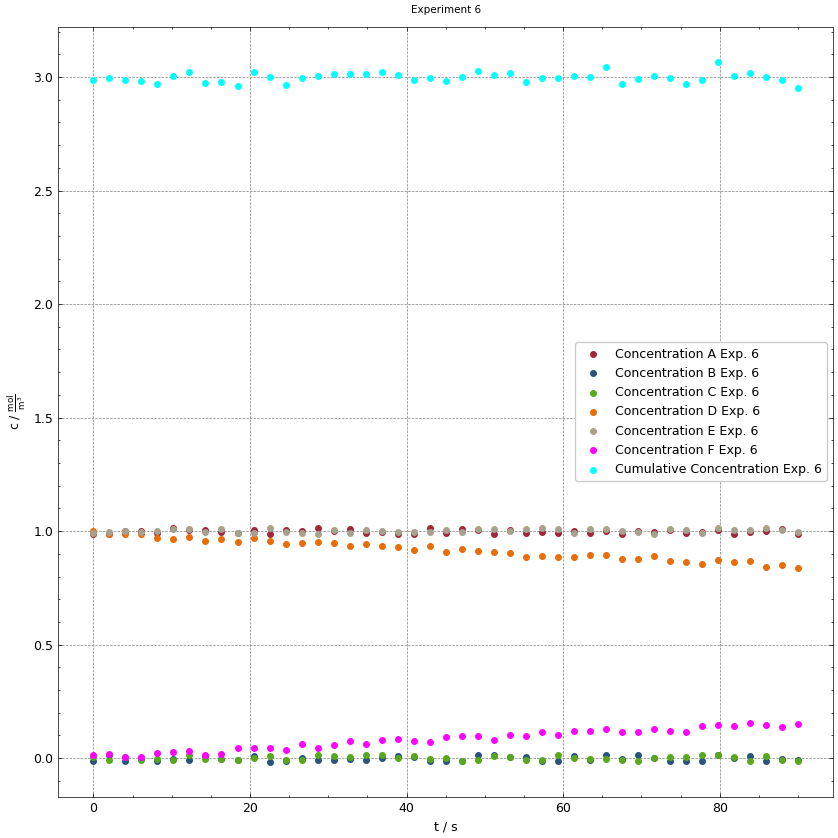

In [ ]:
# Automatic plotting of all experiments

# =============================================================================
# Automatic visualization of all experiments
# Each experiment is plotted separately to inspect concentration trends,
# identify reactant/product behavior, and verify data consistency.
# =============================================================================


# Define the chemical species included in the reaction system.
# The order here must remain consistent throughout the notebook because
# species indices are later used for array access and ODE calculations.
components = ["A", "B", "C", "D", "E", "F"]


# Assign fixed colors to each species for consistent visualization across
# all experiments and later comparison plots.
colors = {
    "A": iciw_colors.CRIMSON,
    "B": iciw_colors.CERULEAN,
    "C": iciw_colors.KELLYGREEN,
    "D": iciw_colors.FLAME,
    "E": iciw_colors.DRAB,
    "F": "magenta"
}


# Loop through all experimental datasets automatically.
# This avoids manually generating plots for each experiment.
for exp in range(1, nex + 1):

    # Convert experiment numbering from human-readable format (1-based)
    # to Python indexing format (0-based).
    exp_idx = exp - 1

    # Create a new figure for the current experiment
    fig, ax = plt.subplots(figsize=(10, 10))

    # Initialize cumulative concentration vector.
    # This is used as an approximate mass balance consistency check.
    cumulative = 0


    # -------------------------------------------------------------------------
    # Plot concentration profiles of all species
    # -------------------------------------------------------------------------
    for comp in components:

        # Determine the row index corresponding to the current species
        comp_idx = components.index(comp)

        # Plot experimental concentration measurements as scatter points.
        # Scatter plots are preferred here because experimental data consists
        # of discrete sampling points rather than continuous measurements.
        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )

        # Add current species concentration to cumulative concentration.
        # If total concentration remains approximately constant, it indicates
        # acceptable mass conservation and reasonable experimental quality.
        cumulative += exp_concs[exp_idx][comp_idx, :]


    # -------------------------------------------------------------------------
    # Plot cumulative concentration profile
    # -------------------------------------------------------------------------
    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )


    # -------------------------------------------------------------------------
    # Plot formatting
    # -------------------------------------------------------------------------

    # Set x-axis label (time)
    ax.set_xlabel("t / s")

    # Set y-axis label (species concentration)
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')

    # Display legend containing all plotted species
    ax.legend()

    # Add experiment title for easier identification
    ax.set_title(f"Experiment {exp}")

    # Display final plot
    plt.show()


## 3 Hypothesis
### 3.1 Data Editing

Before the Differential Equation containing the whole reaction network can be set up the data has to be edited.
The experimental measurements contain small noise that can produce slightly negative values, which physically impossible. These are clipped to zero.

For further simplification the inital concentrations are approximated by either 1 or 0. Since the measurement noise can impact these values, or make them negative, any inital concentration above 0.5 is set to 1 and below 0.5 to 0.

Each experiment only involves certain species. Species that are not fed in and cannot be produced (given the reaction network) are forced to zero. This avoids fitting noise in inactive channels and improves solver stability. These species are identified via the plotting of the raw data earlier.
Here the following components are "inert":
- Experiment 2: A, B and E,
- Experiment 3: A, B, C and E
- Experiment 4: A, B and E
- Experiment 5: B
- Experiment 6: A, B, C and E


In [ ]:
# Negative concentration values to zero
for i in range(nex):
    exp_concs[i] = np.clip(exp_concs[i], 0.0, None)
 
# Round initial conditions to binary (0 or 1) 
for i in range(nex):
    c_inits[i] = np.where(c_inits[i] >= 0.5, 1.0, 0.0)
 

# Assigning index for each component
comp_idx = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3,
    "E": 4,
    "F": 5
}
 
# Components to zero in each experiment
zero_dict = {
    2: ["A", "B", "E"],
    3: ["A", "B", "C", "E"],
    4: ["A", "B", "E"],
    5: ["B"],
    6: ["A", "B", "C", "E"]
}
 
for exp, comps in zero_dict.items():
 
    exp_idx = exp - 1   # convert to 0-based index
 
    for comp in comps:
 
        row = comp_idx[comp]   # find the row index for this species
 
        # Set all time points of this species to zero in this experiment
        exp_concs[exp_idx][row, :] = 0.0
        # Also zero the initial condition for consistency
        c_inits[exp_idx][row] = 0.0
 
# Re-flatten data after zeroing 
exp_concs_flat = np.array([])
 
for i in range(nex):
    exp_concs_flat = np.append(exp_concs_flat, exp_concs[i])

### 3.2 Reaction network hypothesis

#### Experiment 1 
Experiment 1 contains all components; therefore, no unique reaction pathway can be identified directly from this experiment alone.

Components A and B are present at t=0 and are therefore considered initial reactants. Since the concentration profile of A approaches a plateau at longer reaction times, an equilibrium involving A may exist.

The decrease in concentrations of A and B indicates the formation of at least one intermediate species. Whether A and B react directly with each other or participate in separate reactions cannot be concluded unambiguously from this experiment alone.

Component C most likely acts as an intermediate species, as its concentration reaches a maximum during the early stage of the reaction before decreasing again.

#### Experiment 2 
In Experiment 2, only component C is initially present. 
During the reaction, components D and eventually F are formed.

\begin{equation}
    \nu_\mathrm{C, 2} C \rightarrow \nu_\mathrm{D, 2} D \rightarrow  \nu_\mathrm{F, 2} F \\
\end{equation}

From the cumulative concentration profiles, it follows that all stoichiometric coefficients are equal to 1. The resulting reaction network is therefore:

\begin{equation}
    C \rightarrow D \rightarrow  F \\
\end{equation}

#### Experiment 3 
In Experiment 3, only component D is initially present, and component F is formed over time.

This confirms that the formation of F originates solely from D and does not require the simultaneous presence of C.

Using the stoichiometry derived from the cumulative concentrations, the reaction can be written as:
\begin{equation}
    D \rightarrow  F \\
\end{equation}

#### Experiment 4 
Experiment 4 is comparable to Experiment 2, with the exception that component B is additionally present.

Since the concentration profiles remain unchanged compared to Experiment 2, component B can be considered inert with respect to components C, D, and F.

Furthermore component B is reacting with A.
From experiment 1, where component E is not present at the beginning can be 

#### Experiment 5 
In Experiment 5, components A and C are initially present, leading to the formation of D, E, and F.
From Experiments 2 and 3, the reaction pathway
\begin{equation}
    C \rightarrow D \rightarrow  F \\
\end{equation}
has already been established.

The additional formation of component E suggests a further reaction involving A. Two possible pathways can initially be proposed:

\begin{equation}
    A \rightarrow E \\
\end{equation}
or
\begin{equation}
    A + C \rightarrow E \\
\end{equation}

#### Experiment 6 
In Experiment 6, components A and E remain unchanged, while D continues to react to F.

This observation indicates that the formation of E does not occur in the absence of C. Consequently, the reaction

\begin{equation}
    A \rightarrow E \\
\end{equation}

can be excluded.

Therefore, the formation of E is most likely described by:

\begin{equation}
    A + C \rightarrow E \\
\end{equation}

#### Full reaction network

From the findings of all Experiments the following reaction network can be assertained:

\begin{equation}
    A + B \rightarrow C \\
\end{equation}

\begin{equation}
    A + C \rightarrow E \\
\end{equation}

\begin{equation}
    C \rightarrow D \\
\end{equation}

\begin{equation}
    D \rightarrow F \\
\end{equation}

### 3.3 Differential Equation

After editing the data and setting up the reaction network the Differential Equation can be set up.
Here the assumption is established, that every component has the reaction order 1.

In [ ]:
def ode(t, c, k):
    """
    Input:
    t: float
        time of the calculation/experiments, size [nt]
    c: array
        concentration values at time t, size [nc]
        c[0] = c_A; c[1] = c_B; c[2] = c_C; c[3] = c_D; c[4] = c_E; c[5] = c_F
    k: array
        kinetic coefficients for all reactions, size [nr]
    Output:
    dcdt: array
        derivatives of the concentration over time, size [nc]
    """
    dcdt = np.zeros_like(c)
 
    # Calculate reaction rates
    r0 = k[0] * c[0] * c[1]     # A + B -> C  (second order)
    r1 = k[1] * c[0] * c[2]     # A + C -> E  (second order)
    r2 = k[2] * c[2]            # C -> D      (first order)
    r3 = k[3] * c[3]            # D -> F      (first order)
 
    # Mass balances (stoichiometry is 1 for all reactions)
    dcdt[0] = - r0 - r1         # dA/dt: consumed in r0 and r1
    dcdt[1] = - r0              # dB/dt: consumed only in r0
    dcdt[2] = + r0 - r1 - r2    # dC/dt: produced in r0, consumed in r1 and r2
    dcdt[3] = + r2 - r3         # dD/dt: produced in r2, consumed in r3
    dcdt[4] = + r1              # dE/dt: produced only in r1
    dcdt[5] = + r3              # dF/dt: produced only in r3
    return dcdt

The `sim_exp` function solves the functions of the `ode` to simulate an actual experiment.
The `sim_multiple_exps` function simulates multiple experiments and returns the concentration profiles for each experiment.
The `residual` function lets lmfit compare the simulation with the experimental data. The `residual` function is minimized during parameter fitting.


In [ ]:
# SINGLE EXPERIMENT SIMULATION
def sim_exp(t, c_init, k):
    """
    Input:
    t: array
       array with the time points of the simulation, size [nt]
    c_init: array
        initial concentrations, size [nc]
    k: array
        kinetic coefficients for every reaction, size [nr]
    Output:
    c_sol: array
        concentration values at time t, size [nc, nt]
    """
   # Define the time span from first to last time point
    t_sp = np.array([t[0], t[-1]])
 
    # Numerically integrate the ODE system
    sol = integ.solve_ivp(
        fun=ode,          # ODE function defined above
        t_span=t_sp,      # integration interval [t_start, t_end]
        y0=c_init,        # initial concentrations
        method='LSODA',   # adaptive stiff/non-stiff solver
        t_eval=t,         # return solution at these specific time points
        args=[k]          # pass kinetic constants to the ODE function
    )
    c_sol = sol.y   # shape: [nc x nt]
    return c_sol

# MULTI-EXPERIMENT SIMULATION
def sim_multiple_exps(times, k0, k1, k2, k3, c_inits):
    """
    Input:
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    k0: float
        Kinetic parameter of first reaction
    k1: float
        Kinetic parameter of second reaction
    k2: float
        Kinetic parameter of third reaction
    k3: float
        Kinetic parameter of fourth reaction
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    Output:
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]   # pack constants into list for the ODE function
 
    nex = len(times)
    for i in np.arange(0, nex):
        c_0 = c_inits[i]   # initial conditions for experiment i
        t   = times[i]     # time points for experiment i
        conc = sim_exp(t, c_0, k)   # simulate this experiment
        sim_concs.append(conc)
    return sim_concs

# RESIDUAL FUNCTION FOR OPTIMIZATION
def residual(params, times, c_inits, data):
    """
    Input:
    params: Parameters
        Parameter object containing all variables (here only the kinetic constant) to be estimated
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    data: list
        List of arrays with concentration values from experiment, size[n][nc, nt_i].
    Output:
    concs_flat - data: array
        flattened array of differences between simulation and experimental data, size[n*nc*nt_i]
    """
    # number of experiments from length
    # Run simulation with current parameter values
    sim_conc = sim_multiple_exps(
        times,
        params["k0"],
        params["k1"],
        params["k2"],
        params["k3"],
        c_inits
    )
 
    # Flatten simulated results into 1D array (same structure as exp_concs_flat)
    nex = len(times)
    concs_flat = np.array([])
    for i in np.arange(0, nex):
        concs_flat = np.append(concs_flat, sim_conc[i])
 
    # Return residuals — lmfit will minimize the sum of squares of this vector
    return concs_flat - data

Parameter Estimation and Minimizer
In the next step, the parameters k0, k1 and k2 are estimated and adjusted to best fit the simulation to the experimental data.
In the last step, the best-fit parameters are used to simulate the concentration profile based on the hypothesized reaction network.

In [ ]:
# Define the parameters to be estimated with initial guesses and bounds.
# - value: starting guess for the optimizer
# - min/max: physically meaningful bounds (rate constants must be >= 0)
# - vary=True: this parameter will be optimized (set to False to fix a parameter)
params = Parameters()
params.add('k0', value=0.5, min=0, max=10, vary=True)   # A + B -> C
params.add('k1', value=0.5, min=0, max=10, vary=True)   # A + C -> E
params.add('k2', value=0.5, min=0, max=10, vary=True)   # C -> D
params.add('k3', value=0.5, min=0, max=10, vary=True)   # D -> F
 
# Set up the minimizer using Levenberg-Marquardt least squares (default method).
# This algorithm is well suited for nonlinear least squares problems like ODE fitting.
minner = Minimizer(
    residual,           # function to minimize
    params,             # parameters to optimize
    fcn_args=(          # fixed arguments passed to residual function
        t_eval,
        c_inits,
        exp_concs_flat
    )
)
 
# Run the optimization
result = minner.minimize()
 
# Print a detailed fit report including:
# - Final values of k0, k1, k2, k3
# - Standard errors (uncertainty in each parameter)
# - Chi-square and reduced chi-square (overall goodness of fit)
# - Correlations between parameters
report_fit(result)


model = Model(sim_multiple_exps, independent_vars=['times', 'c_inits'])
# initial_fit = model.eval(params, times=t_eval, c_inits=c_inits)
# Run one final simulation using the best-fit parameters
best_fit = sim_multiple_exps(
    times=t_eval,
    k0=result.params['k0'],
    k1=result.params['k1'],
    k2=result.params['k2'],
    k3=result.params['k3'],
    c_inits=c_inits
)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 52
    # data points      = 1620
    # variables        = 4
    chi-square         = 0.12094217
    reduced chi-square = 7.4840e-05
    Akaike info crit   = -15386.2513
    Bayesian info crit = -15364.6906
[[Variables]]
    k0:  0.20257775 +/- 0.00129686 (0.64%) (init = 0.5)
    k1:  0.09843743 +/- 3.8703e-04 (0.39%) (init = 0.5)
    k2:  0.05053079 +/- 1.2732e-04 (0.25%) (init = 0.5)
    k3:  0.00171088 +/- 1.0860e-05 (0.63%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.4472
    C(k0, k1) = +0.2827


Plotting results
The simulated concentration profiles are then plotted alongside the experimental data for comparison.

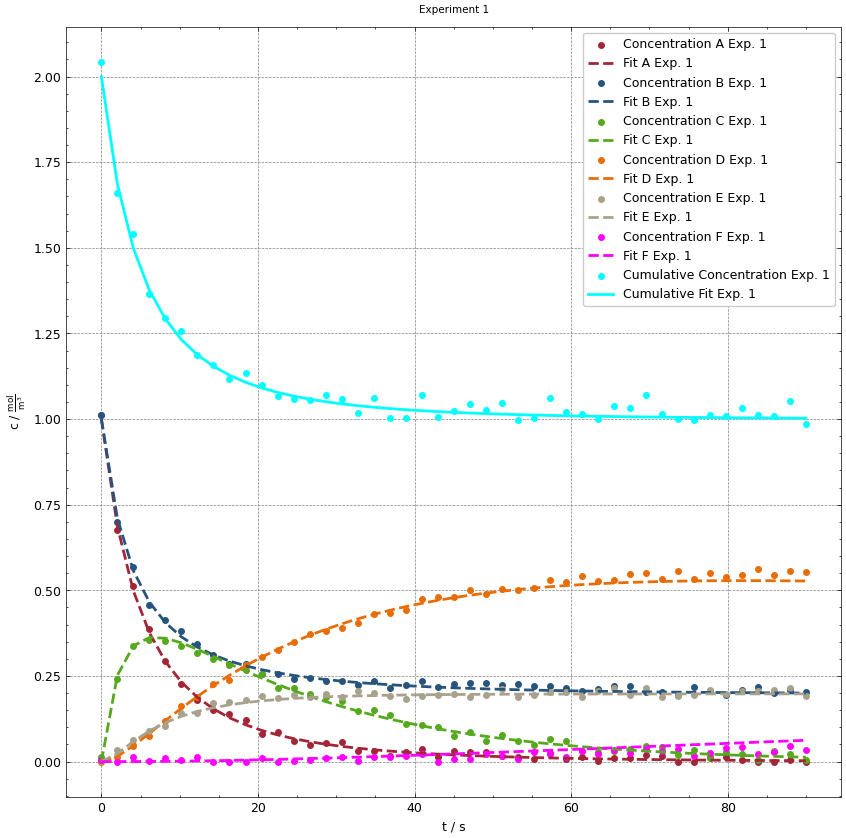

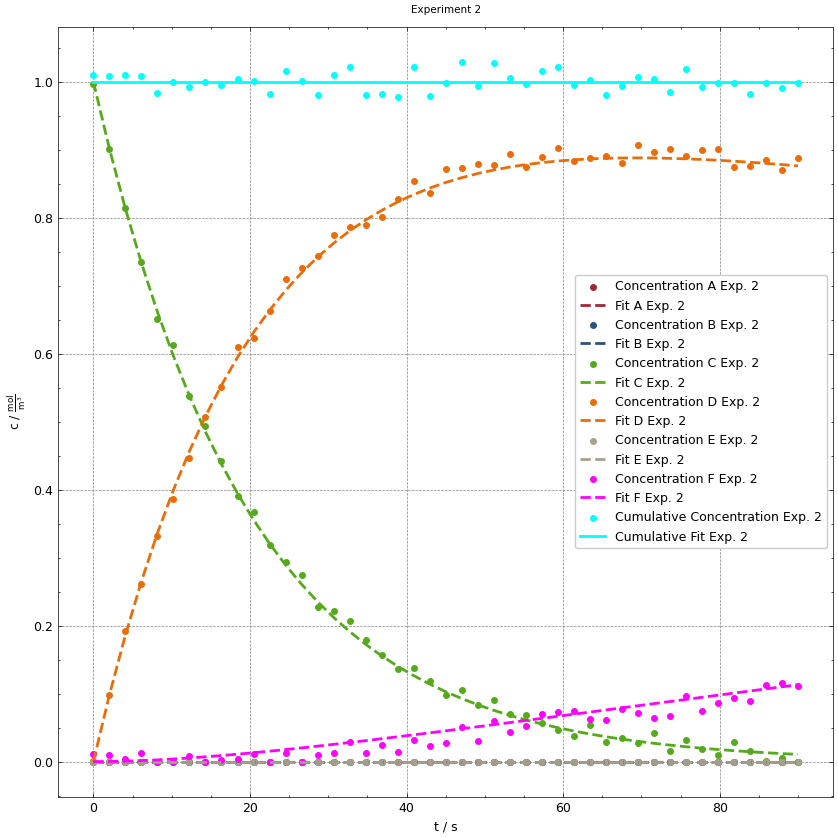

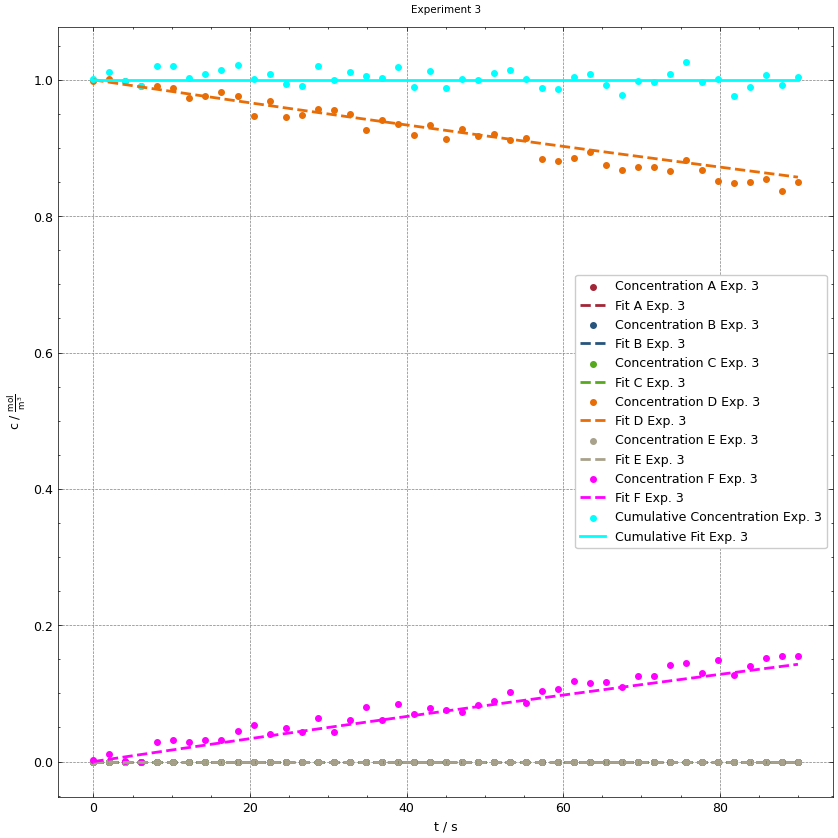

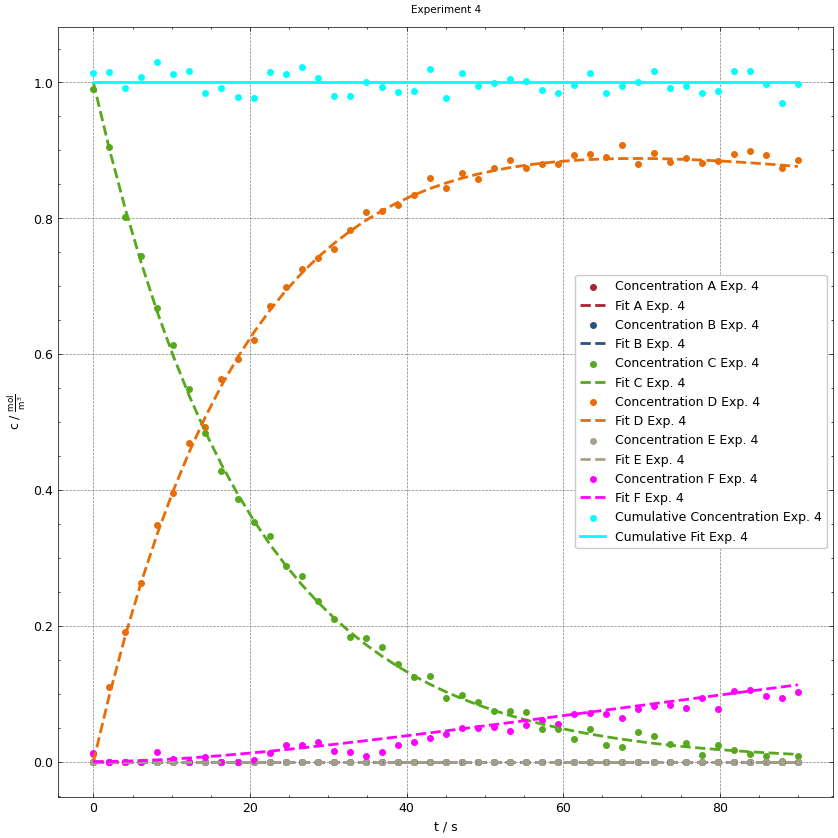

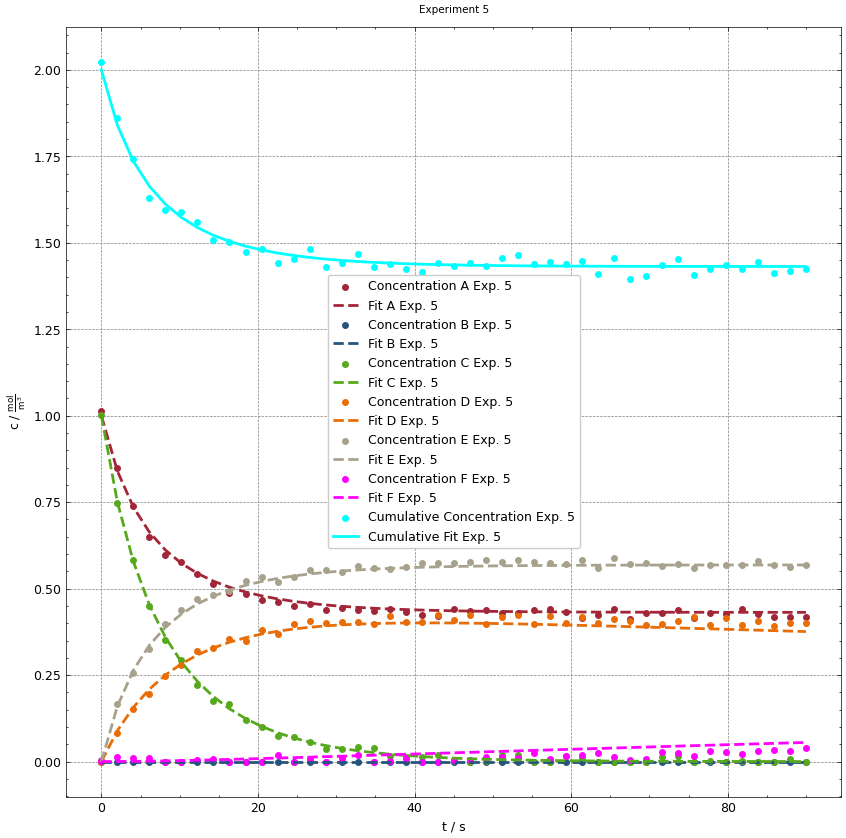

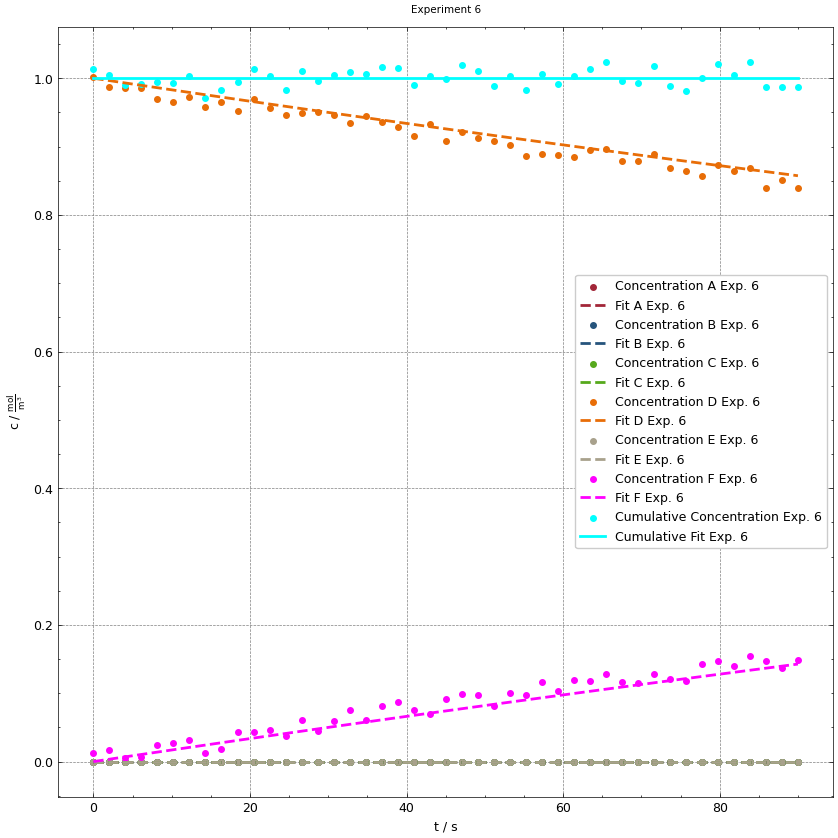

In [ ]:
# Plot each experiment: dots = measured data, dashed lines = model fit
for exp in range(1, nex + 1):
 
    exp_idx = exp - 1           # convert to 0-based index
    fig, ax = plt.subplots(figsize=(10, 6))
    cumulative     = 0          # sum of measured concentrations
    cumulative_fit = 0          # sum of simulated concentrations
    fit_exp = best_fit[exp - 1] # simulated result for this experiment [nc x nt]
 
    for comp in components:
        comp_idx_val = components.index(comp)
 
        # Plot measured concentration (dots)
        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx_val, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )
 
        # Plot simulated concentration (dashed line, same color)
        ax.plot(
            t_eval[exp_idx],
            fit_exp[comp_idx_val, :],
            label=f"Fit {comp} Exp. {exp}",
            color=colors[comp],
            linewidth=2,
            linestyle="--"
        )
 
        # Accumulate totals for mass balance check
        cumulative     += exp_concs[exp_idx][comp_idx_val, :]
        cumulative_fit += fit_exp[comp_idx_val, :]
 
    # Plot measured cumulative concentration (mass balance check)
    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )
 
    # Plot simulated cumulative concentration
    # Should match measured cumulative if mass is conserved in the model
    ax.plot(
        t_eval[exp_idx],
        cumulative_fit,
        label=f"Cumulative Fit Exp. {exp}",
        color="cyan",
        linewidth=2
    )
 
    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.set_title(f"Experiment {exp}")
    ax.legend()
    plt.show()

From the plots above the reaction network is validated.
To further enhance the accuracity the measurement noise is weighted.
Additional the reaction of
\begin{equation}
    D \rightarrow F
\end{equation}
is set to reaction order 2.

To remove confusion and possible errors from running code cells above again every function is defined new with _ro (for reaction order) as a suffix.

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 1620
    # variables        = 4
    chi-square         = 80.5798721
    reduced chi-square = 0.04986378
    Akaike info crit   = -4853.51071
    Bayesian info crit = -4831.94998
[[Variables]]
    k0:  0.19918549 +/- 0.00116064 (0.58%) (init = 0.5)
    k1:  0.10008736 +/- 3.8714e-04 (0.39%) (init = 0.5)
    k2:  0.05000353 +/- 1.1473e-04 (0.23%) (init = 0.5)
    k3:  0.00202089 +/- 1.1400e-05 (0.56%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k1, k2) = +0.3548
    C(k0, k1) = +0.2916


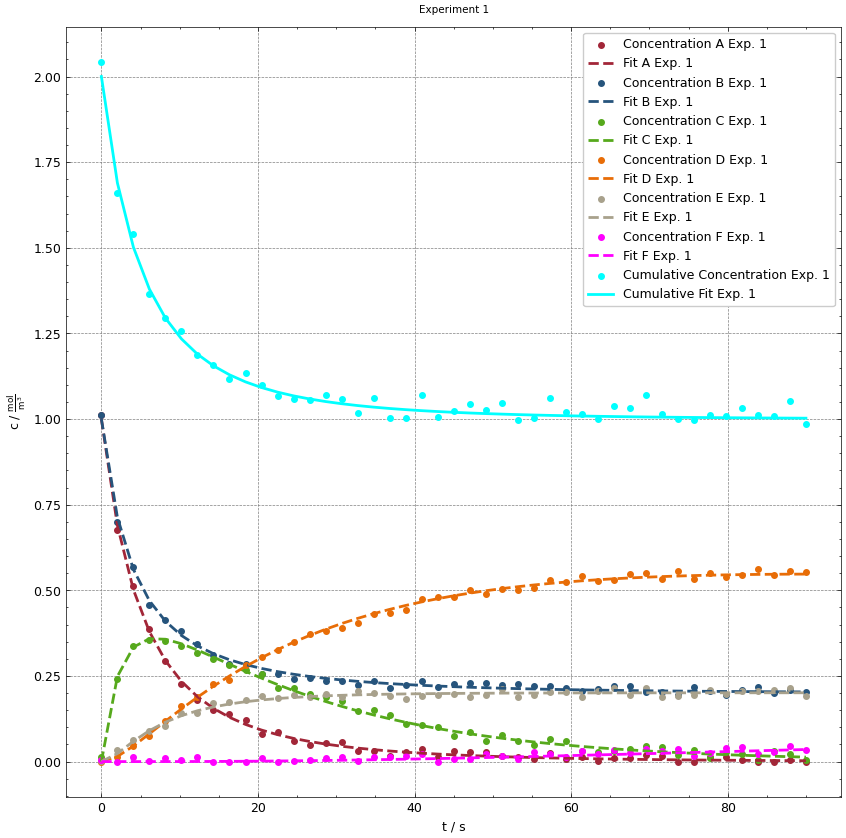

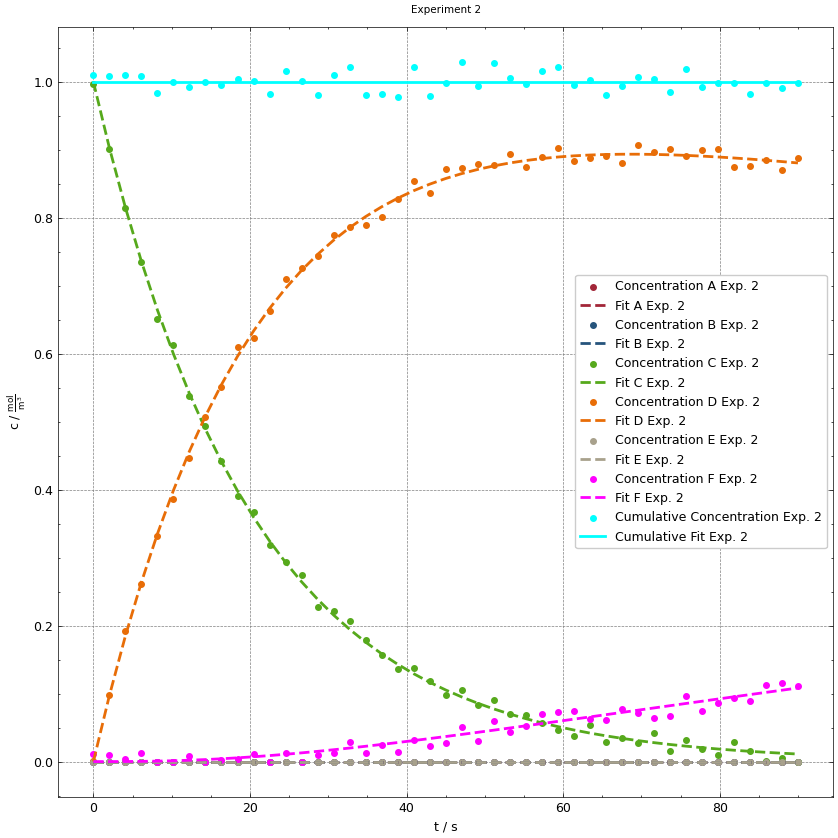

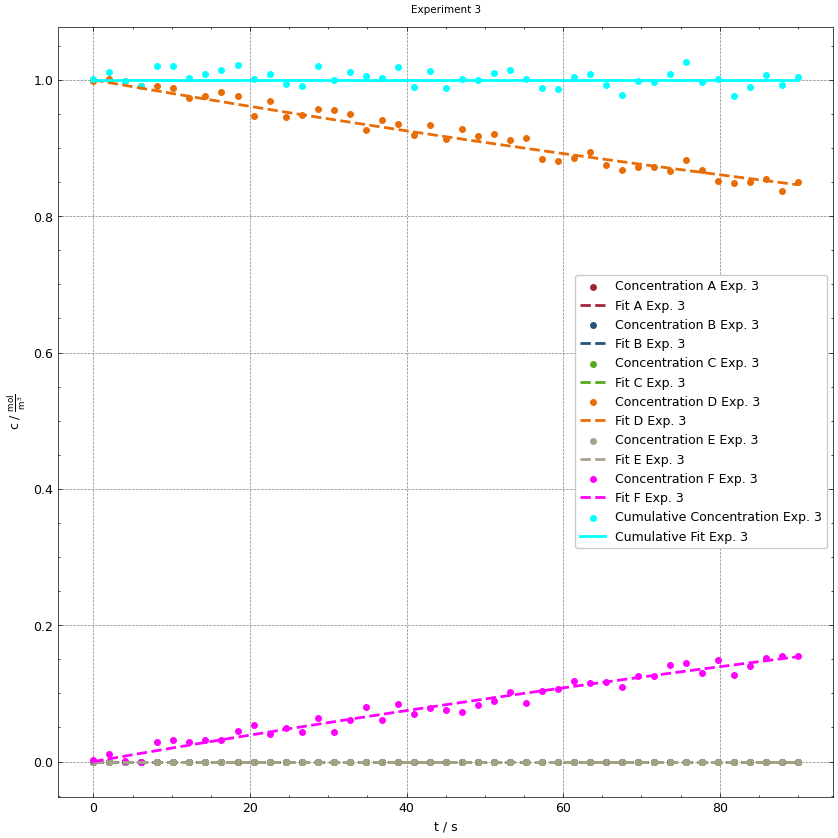

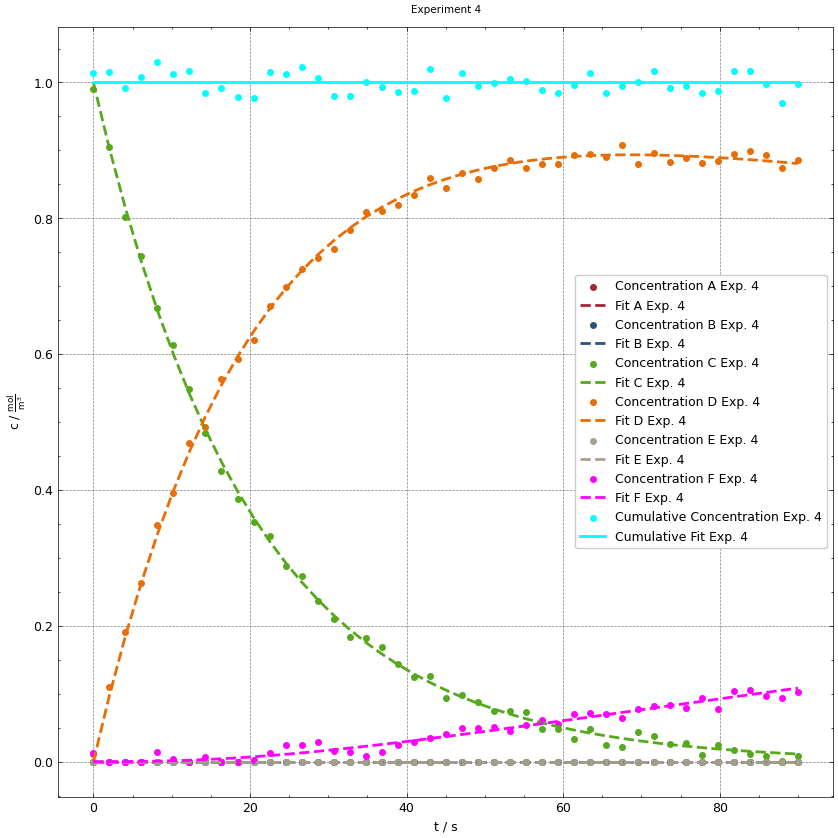

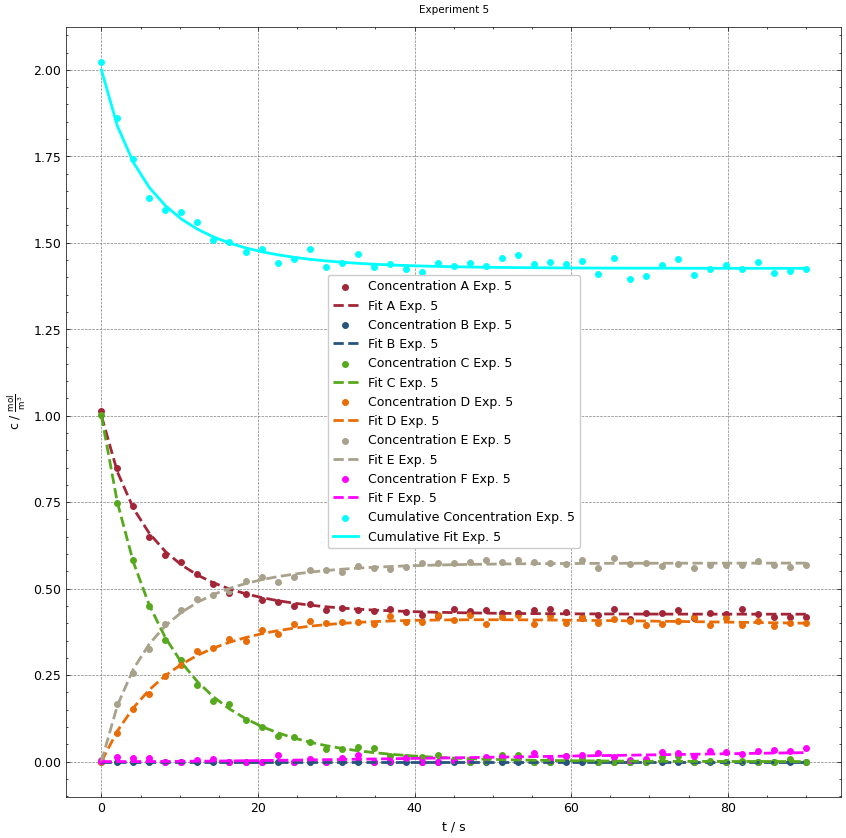

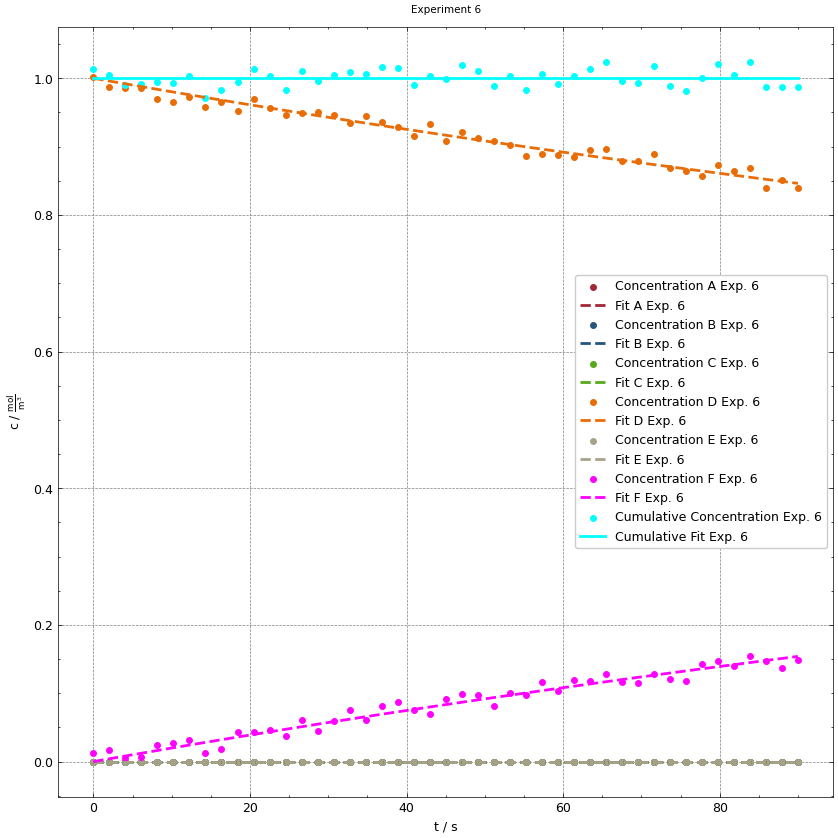

In [ ]:
def ode_ro(t, c, k):
    """
    Input:
    t: float
        time of the calculation/experiments, size [nt]
    c: array
        concentration values at time t, size [nc]
        c[0] = c_A; c[1] = c_B; c[2] = c_C; c[3] = c_D; c[4] = c_E; c[5] = c_F
    k: array
        kinetic coefficients for all reactions, size [nr]
    Output:
    dcdt: array
        derivatives of the concentration over time, size [nc]
    """
    dcdt = np.zeros_like(c)

    # calculating the rates for each reaction
    r0 = k[0] * c[0] * c[1]                 # reaction 1: A + B -> C 
    r1 = k[1] * c[0] * c[2]                 # reaction 2: A + C -> E 
    r2 = k[2] * c[2]                        # reaction 3:     C -> D 
    r3 = k[3] * np.power(c[3], 2)           # reaction 4:     D -> F

    # calculating the derivatives for each component
    dcdt[0] = - r0 - r1
    dcdt[1] = - r0
    dcdt[2] = + r0 - r1 - r2
    dcdt[3] = + r2 - r3
    dcdt[4] = + r1
    dcdt[5] = + r3
    return dcdt

def sim_exp_ro(t, c_init, k):
    """
    Input:
    t: array
       array with the time points of the simulation, size [nt]
    c_init: array
        initial concentrations, size [nc]
    k: array
        kinetic coefficients for every reaction, size [nr]
    Output:
    c_sol: array
        concentration values at time t, size [nc, nt]
    """
    t_sp = np.array([t[0], t[-1]])
    sol = integ.solve_ivp(fun=ode_ro, t_span=t_sp, y0=c_init, method='LSODA', t_eval=t, args=[k])
    c_sol = sol.y
    return c_sol

def sim_multiple_exps_ro(times, k0, k1, k2, k3, c_inits):
    """
    Input:
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    k0: float
        Kinetic parameter of first reaction
    k1: float
        Kinetic parameter of second reaction
    k2: float
        Kinetic parameter of third reaction
    k3: float
        Kinetic parameter of fourth reaction
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    Output:
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = sim_exp_ro(t, c_0, k)
        sim_concs.append(conc)
    return sim_concs

def residual(params, times, c_inits, data):
    """
    Input:
    params: Parameters
        Parameter object containing all variables (here only the kinetic constant) to be estimated
    times: list
        List of arrays with times for each experiment, size [n][nt_i,]
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]
    data: list
        List of arrays with concentration values from experiment, size[n][nc, nt_i].
    Output:
    concs_flat - data: array
        flattened array of differences between simulation and experimental data, size[n*nc*nt_i]
    """
    # number of experiments from length
    sim_conc = sim_multiple_exps_ro(
        times, 
        params["k0"], 
        params["k1"], 
        params["k2"], 
        params["k3"], 
        c_inits)

    nex = len(times)
    concs_flat = np.array([])
    for i in np.arange(0, nex):
        concs_flat = np.append(concs_flat, sim_conc[i])

    # weighting
    sigma = 0.02 + 0.05 * np.abs(data)
    
    return (concs_flat - data) / sigma

params = Parameters()
params.add('k0', value=0.5, min=0, max=10, vary=True)
params.add('k1', value=0.5, min=0, max=10, vary=True)
params.add('k2', value=0.5, min=0, max=10, vary=True)
params.add('k3', value=0.5, min=0, max=10, vary=True)

minner = Minimizer(residual, 
                   params, 
                   fcn_args=(t_eval, 
                             c_inits, 
                             exp_concs_flat))
result = minner.minimize()
report_fit(result)


model_ro = Model(sim_multiple_exps_ro, independent_vars=['times', 'c_inits'])
# initial_fit = model.eval(params, times=t_eval, c_inits=c_inits)
best_fit_ro = sim_multiple_exps_ro(times=t_eval, k0=result.params['k0'], k1=result.params['k1'], k2=result.params['k2'], k3=result.params['k3'], c_inits=c_inits)

for exp in range(1, nex + 1):

    exp_idx = exp - 1
    fig, ax = plt.subplots(figsize=(10,10))
    cumulative = 0
    cumulative_fit = 0
    fit_exp = best_fit_ro[exp - 1]


    for comp in components:
        comp_idx = components.index(comp)
        ax.scatter(
            t_eval[exp_idx],
            exp_concs[exp_idx][comp_idx, :],
            label=f"Concentration {comp} Exp. {exp}",
            color=colors[comp],
            marker="o"
        )

        ax.plot(
            t_eval[exp_idx],
            fit_exp[comp_idx, :],
            label=f"Fit {comp} Exp. {exp}",
            color=colors[comp],
            linewidth=2,
            linestyle="--"
        )


        cumulative += exp_concs[exp_idx][comp_idx, :]
        cumulative_fit += fit_exp[comp_idx, :]

    # Plot cumulative concentration
    ax.scatter(
        t_eval[exp_idx],
        cumulative,
        label=f"Cumulative Concentration Exp. {exp}",
        color="cyan",
        marker="o"
    )

    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.legend()
    ax.set_title(f"Experiment {exp}")

    # cumulative fitted curve
    ax.plot(
        t_eval[exp_idx],
        cumulative_fit,
        label=f"Cumulative Fit Exp. {exp}",
        color="cyan",
        linewidth=2
    )

    ax.set_xlabel("t / s")
    ax.set_ylabel(r'$\mathrm{c}\; / \ \mathrm{\frac{mol}{m^3}}$')
    ax.set_title(f"Experiment {exp}")
    ax.legend()
    plt.show()

## Discussion

The fitted ODE model shows good agreement with the experimental concentration profiles across all six experiments, indicating that the proposed reaction network describes the system behavior reasonably well. The reaction with the largest rate constant proceeds most rapidly, while the slowest reaction causes intermediate species to accumulate temporarily before further conversion. The results also demonstrate that the actual reaction rate depends not only on the kinetic constant but also on reactant concentrations. Remaining deviations may originate from measurement noise, neglected side reactions, and the assumption of ideal isothermal operation.

## Conclusion

In this assignment, experimental concentration data from an isothermal batch reactor were analyzed to identify a reaction network and estimate kinetic parameters. A system of ordinary differential equations was developed and fitted to the experimental data using nonlinear least-squares optimization. The resulting model successfully reproduced the main concentration trends observed in all experiments. Although the fit quality was satisfactory, the model still assumes ideal kinetics and constant temperature. Future improvements could include estimating reaction orders, incorporating Arrhenius temperature dependence, and adding energy balances for non-isothermal reactor behavior.